In [3]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")
print(sentiment.shape)
print(trades.shape)

print(sentiment.info())
print(trades.info())

(2644, 4)
(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Sta

In [5]:
sentiment.isnull().sum()
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
sentiment.duplicated().sum()
trades.duplicated().sum()

0

In [36]:

sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True)
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp ist'].dt.date

In [40]:
print(sentiment.head())
print(trades[['timestamp ist', 'date']].head())

merged = pd.merge(trades, sentiment, on='date', how='inner')

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
        timestamp ist        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [82]:
merged.columns = merged.columns.str.strip().str.lower()

daily_pnl = merged.groupby(['date', 'account'])['closed pnl'].sum().reset_index()

merged['win'] = merged['closed pnl'] > 0
win_rate = merged.groupby('account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

print("Daily PnL:")
print(daily_pnl.head())
print("\nWin Rate:")
print(win_rate.head())

Daily PnL:
         date                                     account  closed pnl
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000

Win Rate:
                                      account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [84]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')
avg_trade_size = merged.groupby('account')['size usd'].mean().reset_index()
avg_trade_size.rename(columns={'size usd': 'avg_size_usd'}, inplace=True)
long_short = merged.groupby(['date', 'side']).size().unstack(fill_value=0)

summary = daily_pnl.merge(win_rate, on='account', how='left')
summary = summary.merge(avg_trade_size, on='account', how='left')

print("\nTrades per Day:")
print(trades_per_day.head())

print("\nAverage Trade Size:")
print(avg_trade_size.head())

print("\nLong/Short:")
print(long_short.head())


Trades per Day:
         date  trade_count
0  2023-05-01            3
1  2023-12-05            9
2  2023-12-14           11
3  2023-12-15            2
4  2023-12-16            3

Average Trade Size:
                                      account  avg_size_usd
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782

Long/Short:
side        BUY  SELL
date                 
2023-05-01    3     0
2023-12-05    7     2
2023-12-14    5     6
2023-12-15    2     0
2023-12-16    3     0


  classification  closed pnl
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


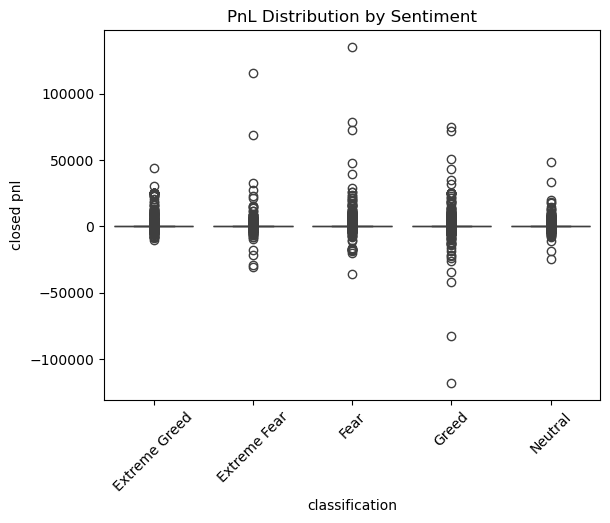

In [86]:
#ANALYSIS - Part B
pnl_by_sentiment = merged.groupby('classification')['closed pnl'].mean().reset_index()
print(pnl_by_sentiment)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

  classification  trade_count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686
  classification     size usd
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661
side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


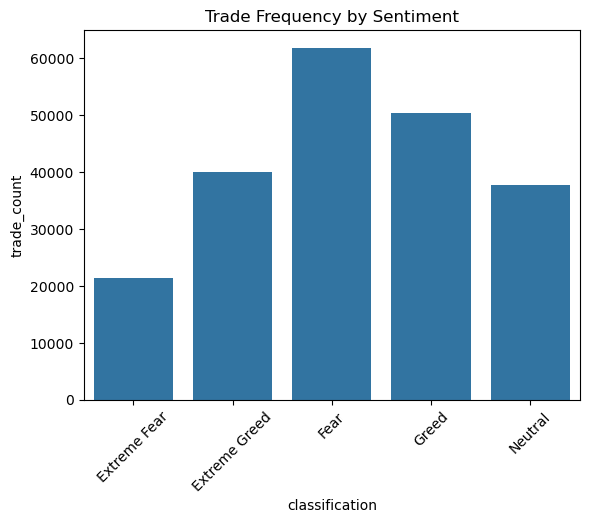

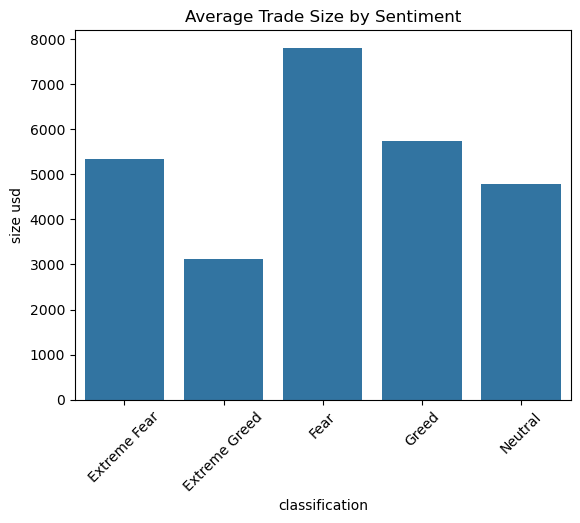

In [88]:

trades_sentiment = merged.groupby('classification').size().reset_index(name='trade_count')
print(trades_sentiment)
size_sentiment = merged.groupby('classification')['size usd'].mean().reset_index()
print(size_sentiment)

long_short_sentiment = merged.groupby(['classification', 'side']).size().unstack(fill_value=0)
print(long_short_sentiment)

plt.figure()
sns.barplot(x='classification', y='trade_count', data=trades_sentiment)
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()
plt.figure()
sns.barplot(x='classification', y='size usd', data=size_sentiment)
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

                                      account    closed pnl segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  Winner
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04  Winner
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04   Loser
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05  Winner
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05  Winner


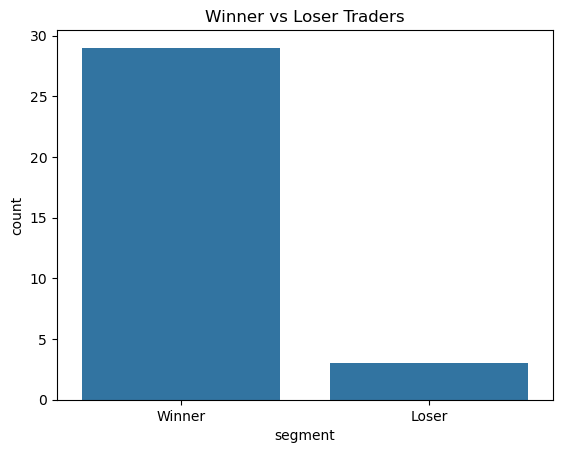

In [90]:
trader_pnl = merged.groupby('account')['closed pnl'].sum().reset_index()
trader_pnl['segment'] = trader_pnl['closed pnl'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

print(trader_pnl.head())
plt.figure()
sns.countplot(x='segment', data=trader_pnl)
plt.title("Winner vs Loser Traders")
plt.show()

Threshold (Top 25%): 8862.5
                                      account  trade_count frequency
0  0xbee1707d6b44d4d52bfe19e41f8a828645437aab        40184  Frequent
1  0xbaaaf6571ab7d571043ff1e313a9609a10637864        21192  Frequent
2  0xa0feb3725a9335f49874d7cd8eaad6be45b27416        15605  Frequent
3  0x8477e447846c758f5a675856001ea72298fd9cb5        14998  Frequent
4  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23        14733  Frequent


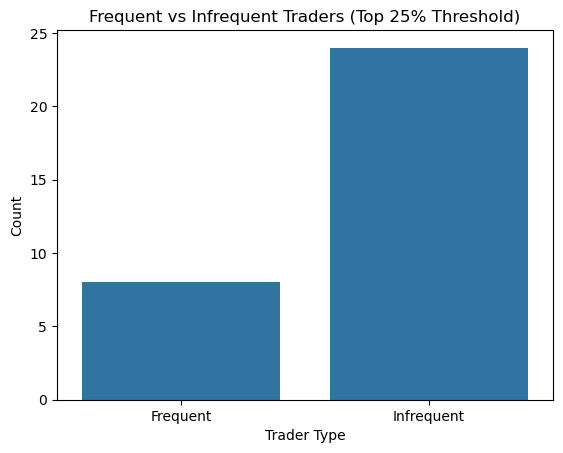

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
trade_counts = merged['account'].value_counts().reset_index()
trade_counts.columns = ['account', 'trade_count']
threshold = trade_counts['trade_count'].quantile(0.75)

trade_counts['frequency'] = trade_counts['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)
print("Threshold (Top 25%):", threshold)
print(trade_counts.head())

plt.figure()
sns.countplot(x='frequency', data=trade_counts)
plt.title("Frequent vs Infrequent Traders (Top 25% Threshold)")
plt.xlabel("Trader Type")
plt.ylabel("Count")
plt.show()

                                      account      pnl_std
0  0x083384f897ee0f19899168e3b1bec365f52a9012  4692.452329
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   134.073473
2  0x271b280974205ca63b716753467d5a371de622ab   542.182659
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   113.269353
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   255.829091


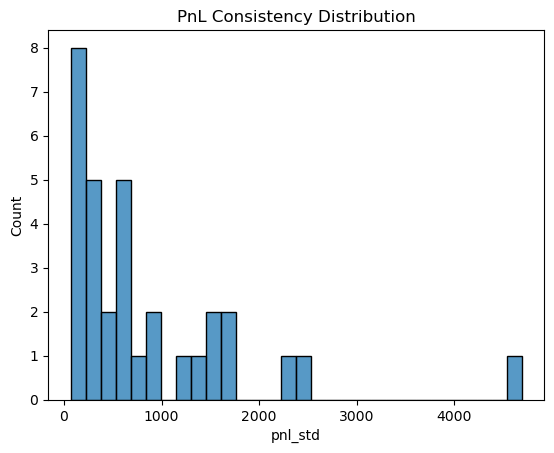

In [94]:
consistency = merged.groupby('account')['closed pnl'].std().reset_index()
consistency.rename(columns={'closed pnl': 'pnl_std'}, inplace=True)

print(consistency.head())
plt.figure()
sns.histplot(consistency['pnl_std'], bins=30)
plt.title("PnL Consistency Distribution")
plt.show()